<a href="https://colab.research.google.com/github/GuruPatel45/Malaria_Detection_ML_Project/blob/main/Malaria_detection_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = '/content/drive/MyDrive/Malaria_Project/cell_images'
img_size = 224
batch_size = 32

In [ ]:
import os
print(os.listdir(data_path))

['Uninfected', 'Parasitized']


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 480 images belonging to 2 classes.
Found 120 images belonging to 2 classes.


In [ ]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=8,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 171s 11s/step - accuracy: 0.6957 - loss: 0.6376 - val_accuracy: 0.9000 - val_loss: 0.2879
Epoch 2/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.9327 - loss: 0.1573 - val_accuracy: 0.8833 - val_loss: 0.2745
Epoch 3/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9521 - loss: 0.1132 - val_accuracy: 0.8917 - val_loss: 0.3083
Epoch 4/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9449 - loss: 0.1085 - val_accuracy: 0.9083 - val_loss: 0.2637
Epoch 5/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9480 - loss: 0.0980 - val_accuracy: 0.9167 - val_loss: 0.2560
Epoch 6/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9665 - loss: 0.1139 - val_accuracy: 0.8917 - val_loss: 0.3336
Epoch 7/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9774 - loss: 0.0892 - val_accuracy: 0.8667 - val_loss: 0.3913
Epoch 8/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9761 - loss: 0.0688 - val_accuracy: 0.8917 - val_loss: 0.306

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 0.4923 - loss: 1.6447 - val_accuracy: 0.9000 - val_loss: 0.2728
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.6413 - loss: 0.7968 - val_accuracy: 0.8667 - val_loss: 0.3006
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.7825 - loss: 0.4512 - val_accuracy: 0.9000 - val_loss: 0.3644
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.8815 - loss: 0.2501 - val_accuracy: 0.9000 - val_loss: 0.3157


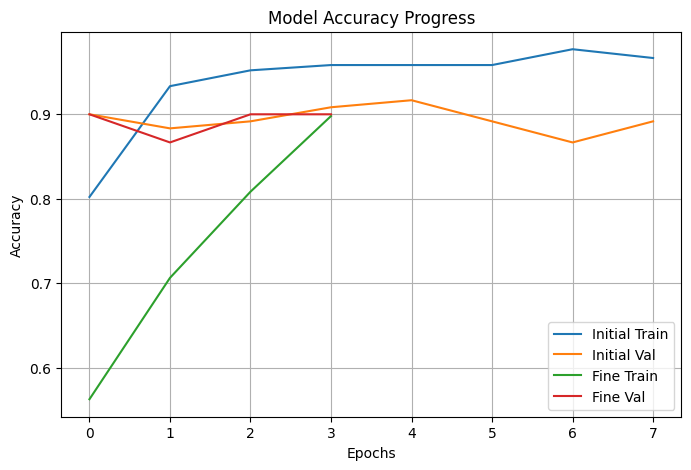

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Initial Train')
plt.plot(history.history['val_accuracy'], label='Initial Val')
plt.plot(history_fine.history['accuracy'], label='Fine Train')
plt.plot(history_fine.history['val_accuracy'], label='Fine Val')
plt.title("Model Accuracy Progress")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step


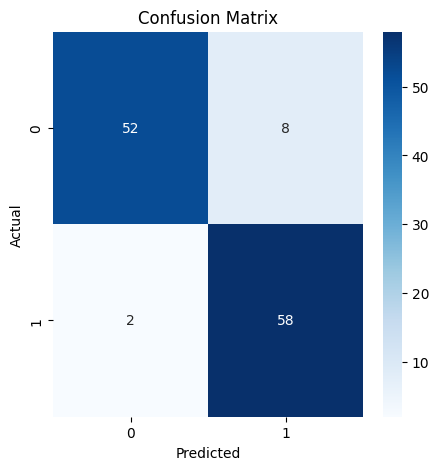

In [ ]:
val_pred_prob = model.predict(val_data)
val_pred = (val_pred_prob > 0.5).astype(int)

cm = confusion_matrix(val_data.classes, val_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


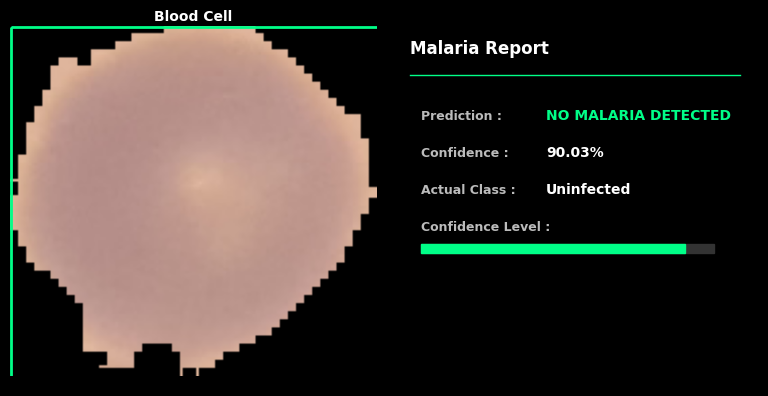

In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def automated_malaria_test(model, data_path):

    classes = ["Parasitized", "Uninfected"]
    chosen_class = random.choice(classes)
    class_path = os.path.join(data_path, chosen_class)
    random_image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, random_image_name)

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    resized = cv2.resize(img_rgb, (224,224))
    normalized = resized / 255.0
    reshaped = np.reshape(normalized, (1,224,224,3))

    prediction = model.predict(reshaped)[0][0]

    if prediction > 0.5:
        result = "NO MALARIA DETECTED"
        confidence = prediction * 100
        result_color = "#00ff88"
    else:
        result = "MALARIA DETECTED"
        confidence = (1 - prediction) * 100
        result_color = "#ff4d4d"

    fig = plt.figure(figsize=(8,4))
    fig.patch.set_facecolor('#000000')

    # -------- IMAGE --------
    ax1 = plt.subplot2grid((1,2),(0,0))
    ax1.imshow(img_rgb)
    ax1.axis("off")

    ax1.add_patch(Rectangle((0,0),224,224,
                            linewidth=2,
                            edgecolor=result_color,
                            facecolor='none'))

    ax1.set_title("Blood Cell",
                  fontsize=10,
                  fontweight='bold',
                  color="white",
                  pad=4)

    # -------- REPORT --------
    ax2 = plt.subplot2grid((1,2),(0,1))
    ax2.axis("off")

    ax2.text(0.05,0.90,"Malaria Report",
             transform=ax2.transAxes,
             fontsize=12,
             fontweight="bold",
             color="white")

    ax2.plot([0.05,0.95],[0.84,0.84],
             transform=ax2.transAxes,
             color=result_color,
             linewidth=1)

    # Better vertical control
    y1 = 0.72
    y2 = 0.62
    y3 = 0.52
    y4 = 0.42  # Confidence Level line

    ax2.text(0.08,y1,"Prediction :", transform=ax2.transAxes,
             fontsize=9, fontweight="bold", color="#bbbbbb")

    ax2.text(0.42,y1,result, transform=ax2.transAxes,
             fontsize=10, fontweight="bold", color=result_color)

    ax2.text(0.08,y2,"Confidence :", transform=ax2.transAxes,
             fontsize=9, fontweight="bold", color="#bbbbbb")

    ax2.text(0.42,y2,f"{confidence:.2f}%", transform=ax2.transAxes,
             fontsize=10, fontweight="bold", color="white")

    ax2.text(0.08,y3,"Actual Class :", transform=ax2.transAxes,
             fontsize=9, fontweight="bold", color="#bbbbbb")

    ax2.text(0.42,y3,chosen_class, transform=ax2.transAxes,
             fontsize=10, fontweight="bold", color="white")

    # -------- CONFIDENCE LEVEL --------
    ax2.text(0.08,y4,"Confidence Level :",
             transform=ax2.transAxes,
             fontsize=9,
             fontweight="bold",
             color="#bbbbbb")

    bar_y = 0.36  # separate clearly below text

    ax2.add_patch(Rectangle((0.08,bar_y),
                            0.80,0.025,
                            transform=ax2.transAxes,
                            color="#333333"))

    ax2.add_patch(Rectangle((0.08,bar_y),
                            0.80*(confidence/100),0.025,
                            transform=ax2.transAxes,
                            color=result_color))

    plt.tight_layout()
    plt.show()


# Run
automated_malaria_test(model, data_path)